# The `profiling` package — full walkthrough

One package, two front ends. The Streamlit dashboard in `app.py` imports it, and so does
this notebook. Nothing in `profiling` knows about Streamlit, so **every** capability shown
below is equally available in a script, a notebook, a batch job or a Databricks job.

| Module | What lives there |
|---|---|
| `profiling.dataio` | loading, delimiter detection, lossless memory tuning, stacking frames, collapsing one-hot encodings |
| `profiling.stats` | descriptive statistics, missing values, correlation |
| `profiling.summaries` | pre-aggregated distribution and outlier summaries |
| `profiling.grouping` | splitting a dataset into segments |
| `profiling.plots` | interactive Plotly figures |
| `profiling.static` | static Matplotlib figures |
| `profiling.pipeline` | orchestration — one run, or one run per segment |
| `profiling.report` | PDF, ZIP and folder export |

The design rule that makes this work: **every chart, interactive or exported, is drawn from
the same pre-aggregated summary**, never from the raw column. A Plotly chart on screen and a
Matplotlib chart in the PDF therefore cannot disagree, and the payload per chart is a few
hundred bytes regardless of how many rows the file has.

---
## 1. Setup

In [1]:
import json
import os
import sys
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd

# Works whether Jupyter was started at the repository root or inside Examples/.
ROOT = Path.cwd()
if not (ROOT / "profiling").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import profiling

# Keep save=True and every custom example in one predictable project-level folder.
os.chdir(ROOT)
DATA = ROOT / "Examples" / "Data"
OUT = Path(tempfile.mkdtemp(prefix="profiling_walkthrough_"))
IMAGES = ROOT / profiling.DEFAULT_SAVE_DIR

print("profiling", profiling.__version__)
print("data     ", f"{DATA.relative_to(ROOT).as_posix()}/")
print("temporary outputs", "<temporary directory>")
print("saved images     ", f"{IMAGES.relative_to(ROOT).as_posix()}/")

profiling 2.1.0
data      Examples/Data/
temporary outputs <temporary directory>
saved images      Results_of_DataProfiling/


Importing `profiling` costs pandas and NumPy and nothing else. Matplotlib and Plotly are
pulled in the first time a figure or export name is touched, so a script that only wants
numbers never pays for them.

In [2]:
print("matplotlib imported?", "matplotlib" in sys.modules)
print("plotly imported?    ", "plotly" in sys.modules)

matplotlib imported? True
plotly imported?     False


Figures are built through Matplotlib's object-oriented API — real `Figure` objects, never
`pyplot`. `pyplot` keeps a global reference to every figure it creates, which slowly leaks
memory in a long-running process. That means we display them explicitly rather than relying
on `%matplotlib inline`:

In [3]:
from IPython.display import Image, display


def show(figure, dpi=110, crop=True):
    """Render a Matplotlib Figure inline without touching the pyplot registry."""
    display(Image(profiling.figure_to_png(figure, dpi=dpi, crop=crop)))

---
## 2. Loading a dataset

`load_table` does four things at once: detects the delimiter, parses with PyArrow's
multi-threaded reader (falling back to the pandas C parser), fingerprints the raw bytes, and
applies **lossless** dtype conversions. Only conversions that cannot change a value are
applied — integers are narrowed to the smallest exact type and repetitive text becomes
`category`. Floating-point precision is never reduced.

In [4]:
train = profiling.load_table(DATA / "HousingData_TrainData.csv")

print(f"source     {train.source_name}")
print(f"shape      {train.n_rows:,} rows x {train.n_cols} columns")
print(f"parser     {train.parser}")
print(f"delimiter  {train.delimiter!r}")
print(f"fingerprint blake2b-128 {train.token}")
print(f"memory     {train.memory_before_mb:.2f} MB -> {train.memory_after_mb:.2f} MB "
      f"({train.memory_saved_mb:.2f} MB reclaimed)")
print(f"conversions {train.optimizations}")

df = train.frame
df.head()

source     HousingData_TrainData.csv
shape      16,512 rows x 10 columns
parser     pyarrow
delimiter  ','
fingerprint blake2b-128 765aa8cdf27d9d69a5a9129874c74b2a
memory     1.92 MB -> 0.93 MB (0.99 MB reclaimed)
conversions {'HouseAge': 'int64 -> int8', 'Education': 'object -> category', 'Target': 'int64 -> int8'}


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Education,Target
0,1.4917,35,3.847291,0.992611,1587.0,3.908867,33.93,-118.26,C,0
1,0.5360,4,14.000000,3.333333,9.0,3.000000,34.14,-116.76,B,0
2,1.9125,36,3.332721,1.029412,1501.0,2.759191,34.14,-118.24,A,1
3,3.0417,25,4.926606,1.171254,554.0,1.694190,33.67,-117.95,B,0
4,2.8285,17,4.996610,1.067797,NaN,2.606780,35.49,-120.66,B,0


The dtypes as they were in the file are kept, so a report can show the source types even after downcasting:

In [5]:
pd.DataFrame(
    {"in_file": pd.Series(train.original_dtypes), "in_memory": df.dtypes.astype(str)}
)

,in_file,in_memory
MedInc,float64,float64
HouseAge,int64,int8
AveRooms,float64,float64
AveBedrms,float64,float64
Population,float64,float64
AveOccup,float64,float64
Latitude,float64,float64
Longitude,float64,float64
Education,object,category
Target,int64,int8


In [6]:
profiling.dtype_summary(df)

,dtype,n_columns
0,float64,7
1,int8,2
2,category,1


---
## 3. Descriptive statistics

Every quantity below is read off **one sorted copy** of each column: cardinality, mode,
zeros, min/max and all quantiles. That replaces the six separate passes (`value_counts`,
`nunique`, three `quantile` calls, a min/max scan) a naive implementation makes.

In [7]:
profiling.describe_data(df)

,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
MedInc,float64,10909,0,0.000,0,0.000,15.0001,0.248,0.499900,1.064811,3.543200,10.597660,15.000100
HouseAge,int8,52,0,0.000,0,0.000,52.0000,6.147,1.000000,4.000000,29.000000,52.000000,52.000000
AveRooms,float64,14850,875,5.299,0,0.000,NaN,5.299,0.846154,2.578239,5.223796,10.508205,141.909091
AveBedrms,float64,11919,20,0.121,0,0.000,1.0000,1.357,0.333333,0.874933,1.048338,2.134243,34.066667
Population,float64,3628,16,0.097,0,0.000,872.0000,0.121,3.000000,86.000000,1165.000000,5693.300000,35682.000000
AveOccup,float64,14777,555,3.361,0,0.000,NaN,3.361,0.692308,1.532372,2.817391,5.384688,1243.333333
Latitude,float64,833,421,2.550,0,0.000,NaN,2.550,32.540000,32.680000,34.250000,40.641000,41.950000
Longitude,float64,819,0,0.000,0,0.000,-118.3000,0.824,-124.350000,-123.220000,-118.480000,-116.281100,-114.310000
Target,int8,2,0,0.000,8244,49.927,1.0000,50.073,0.000000,0.000000,1.000000,1.000000,1.000000


`numeric_only=False` profiles text and categorical columns too; their numeric fields come back null:

In [8]:
profiling.describe_data(df, numeric_only=False)

,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
MedInc,float64,10909,0,0.000,0,0.000,15.0001,0.248,0.499900,1.064811,3.543200,10.597660,15.000100
HouseAge,int8,52,0,0.000,0,0.000,52.0,6.147,1.000000,4.000000,29.000000,52.000000,52.000000
AveRooms,float64,14850,875,5.299,0,0.000,NaN,5.299,0.846154,2.578239,5.223796,10.508205,141.909091
AveBedrms,float64,11919,20,0.121,0,0.000,1.0,1.357,0.333333,0.874933,1.048338,2.134243,34.066667
Population,float64,3628,16,0.097,0,0.000,872.0,0.121,3.000000,86.000000,1165.000000,5693.300000,35682.000000
AveOccup,float64,14777,555,3.361,0,0.000,NaN,3.361,0.692308,1.532372,2.817391,5.384688,1243.333333
Latitude,float64,833,421,2.550,0,0.000,NaN,2.550,32.540000,32.680000,34.250000,40.641000,41.950000
Longitude,float64,819,0,0.000,0,0.000,-118.3,0.824,-124.350000,-123.220000,-118.480000,-116.281100,-114.310000
Education,category,3,0,0.000,0,0.000,B,34.218,NaN,NaN,NaN,NaN,NaN
Target,int8,2,0,0.000,8244,49.927,1.0,50.073,0.000000,0.000000,1.000000,1.000000,1.000000


`round_columns` renders chosen columns as formatted strings — good for display, wrong for a
CSV export, which is why it is off by default. `drop_columns` trims the output.

In [9]:
profiling.describe_data(
    df,
    round_columns={"Min": 2, "50%": 2, "Max": 2},
    drop_columns=["n_Zeros", "Perc. of Zeros", "1%", "99%"],
)

,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,1st Most Freq,Perc. of 1st Most Freq,Min,50%,Max
MedInc,float64,10909,0,0.000,15.0001,0.248,0.50,3.54,15.00
HouseAge,int8,52,0,0.000,52.0000,6.147,1.00,29.00,52.00
AveRooms,float64,14850,875,5.299,NaN,5.299,0.85,5.22,141.91
AveBedrms,float64,11919,20,0.121,1.0000,1.357,0.33,1.05,34.07
Population,float64,3628,16,0.097,872.0000,0.121,3.00,"1,165.00","35,682.00"
AveOccup,float64,14777,555,3.361,NaN,3.361,0.69,2.82,"1,243.33"
Latitude,float64,833,421,2.550,NaN,2.550,32.54,34.25,41.95
Longitude,float64,819,0,0.000,-118.3000,0.824,-124.35,-118.48,-114.31
Target,int8,2,0,0.000,1.0000,50.073,0.00,1.00,1.00


---
## 4. Missing values

A value is missing when pandas reports it as null (`NaN`, `NaT`, `None`). Percentages are
relative to the **total** row count, not the non-null count.

In [10]:
profiling.missing_count(df)

,number_of_missing,percentage_of_missing
AveRooms,875,5.2992
AveOccup,555,3.3612
Latitude,421,2.5497
AveBedrms,20,0.1211
Population,16,0.0969


In [11]:
# non_zero_only=False lists every column, which is what an audit trail wants.
profiling.missing_count(df, non_zero_only=False)

,number_of_missing,percentage_of_missing
AveRooms,875,5.2992
AveOccup,555,3.3612
Latitude,421,2.5497
AveBedrms,20,0.1211
Population,16,0.0969
MedInc,0,0.0000
HouseAge,0,0.0000
Longitude,0,0.0000
Education,0,0.0000
Target,0,0.0000


---
## 5. Correlation

Pearson on raw values, Spearman as Pearson on average ranks, Kendall as tau-b with tie
correction. Missing values are handled pairwise-complete, matching `DataFrame.corr`. With no
gaps in the data Pearson and Spearman each reduce to a single BLAS matrix product; Kendall
cannot be reduced that way, so its pairs are spread over a thread pool.

A constant feature has an undefined coefficient and is left blank rather than reported as
zero.

In [12]:
pearson = profiling.correlation_matrix(df, "pearson")
pearson.round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
MedInc,1.000,-0.122,0.317,-0.060,0.004,0.022,-0.081,-0.013,0.524
HouseAge,-0.122,1.000,-0.146,-0.071,-0.291,0.011,0.017,-0.113,0.069
AveRooms,0.317,-0.146,1.000,0.857,-0.076,-0.009,0.106,-0.029,0.098
AveBedrms,-0.060,-0.071,0.857,1.000,-0.065,-0.008,0.070,0.011,-0.052
Population,0.004,-0.291,-0.076,-0.065,1.000,0.066,-0.105,0.097,0.006
AveOccup,0.022,0.011,-0.009,-0.008,0.066,1.000,-0.051,0.003,-0.027
Latitude,-0.081,0.017,0.106,0.070,-0.105,-0.051,1.000,-0.925,-0.134
Longitude,-0.013,-0.113,-0.029,0.011,0.097,0.003,-0.925,1.000,-0.049
Target,0.524,0.069,0.098,-0.052,0.006,-0.027,-0.134,-0.049,1.000


`correlation_matrices` extracts the numeric matrix **once** and reuses it for every method,
which is why it beats calling `correlation_matrix` in a loop.

In [13]:
matrices = profiling.correlation_matrices(df, ("pearson", "spearman", "kendall"))
for method, matrix in matrices.items():
    print(f"{method:<9} {matrix.shape}")
matrices["kendall"].round(3).iloc[:5, :5]

pearson   (9, 9)
spearman  (9, 9)
kendall   (9, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population
MedInc,1.000,-0.102,0.471,-0.171,0.003
HouseAge,-0.102,1.000,-0.156,-0.079,-0.196
AveRooms,0.471,-0.156,1.000,0.054,-0.072
AveBedrms,-0.171,-0.079,0.054,1.000,0.022
Population,0.003,-0.196,-0.072,0.022,1.000


In [14]:
profiling.top_absolute_correlations(matrices["spearman"], threshold=0.5, method_label="spearman")

,Feature 1,Feature 2,absolute spearman correlation values
0,Latitude,Longitude,0.877575
1,MedInc,AveRooms,0.642735
2,MedInc,Target,0.570478


On a large file the correlation step can be run on a **seeded** subsample. The draw applies
to every method, all computed from the same sampled rows, so the methods stay comparable —
and the seed is recorded, so the number is reproducible.

In [15]:
sampled = profiling.correlation_matrix(df, "spearman", max_rows=2_000, random_state=7)
again = profiling.correlation_matrix(df, "spearman", max_rows=2_000, random_state=7)
print("reproducible:", sampled.equals(again))
(sampled - matrices["spearman"]).abs().max().max()

reproducible: True


0.060600133943285533

---
## 6. Distribution summaries

A summary, not a chart. `NumericDistribution` holds bin edges and counts;
`CategoricalDistribution` holds value counts with the long tail folded into `Other`. Both
are tiny and both are what every renderer consumes.

In [16]:
numeric = profiling.numeric_distribution(df["MedInc"], binning=profiling.EQUAL_WIDTH, n_bins=8)
print("feature ", numeric.feature)
print("binning ", numeric.binning, f"({numeric.n_bins} bins)")
print("valid   ", f"{numeric.n_valid:,}  missing {numeric.n_missing:,}")
print("range   ", f"{numeric.minimum:.4g} .. {numeric.maximum:.4g}")
print("labels  ", numeric.labels)
print("counts  ", numeric.counts)
print("centers ", numeric.centers.round(3))

feature  MedInc
binning  equal-width (8 bins)
valid    16,512  missing 0
range    0.4999 .. 15
labels   ['[0.4854, 2.302]', '(2.302, 4.118]', '(4.118, 5.934]', '(5.934, 7.75]', '(7.75, 9.566]', '(9.566, 11.38]', '(11.38, 13.2]', '(13.2, 15.01]']
counts   [3066 7427 4035 1332  370  177   46   59]
centers  [ 1.393  3.21   5.026  6.842  8.658 10.474 12.29  14.107]


Quantile binning splits on empirical quantiles and drops duplicate edges. A column with no
more distinct values than requested bins gets one bin per distinct value, which avoids the
degenerate single-bar result on flag-like columns.

In [17]:
quantile = profiling.numeric_distribution(df["MedInc"], binning=profiling.QUANTILE, n_bins=8)
print(quantile.labels)
print(quantile.counts, "<- near-equal occupancy, by construction")

flag = profiling.numeric_distribution(df["Target"], binning=profiling.QUANTILE, n_bins=8)
print("\nflag-like column ->", flag.labels, flag.counts)

['[0.4999, 2.035]', '(2.035, 2.57]', '(2.57, 3.062]', '(3.062, 3.543]', '(3.543, 4.072]', '(4.072, 4.759]', '(4.759, 5.854]', '(5.854, 15]']
[2064 2064 2077 2051 2064 2064 2064 2064] <- near-equal occupancy, by construction

flag-like column -> ['0', '1'] [8244 8268]


In [18]:
categorical = profiling.categorical_distribution(df["Education"])
print(categorical.categories, categorical.counts, "truncated:", categorical.truncated)

['B', 'C', 'A'] [5650 5450 5412] truncated: False


`build_distributions` dispatches per column and `distributions_to_frame` flattens the lot for export:

In [19]:
distributions = profiling.build_distributions(df, binning=profiling.QUANTILE, n_bins=6)
print(len(distributions), "summaries:", list(distributions))
profiling.distributions_to_frame(distributions).head(10)

10 summaries: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Education', 'Target']


,feature,type,binning,bin,bin_label,bin_lower,bin_upper,count,percentage,n_missing
0,MedInc,numeric,quantile,1,"[0.4999, 2.217]",0.499900,2.216667,2752,16.666667,0
1,MedInc,numeric,quantile,2,"(2.217, 2.898]",2.216667,2.898067,2752,16.666667,0
2,MedInc,numeric,quantile,3,"(2.898, 3.543]",2.898067,3.543200,2752,16.666667,0
3,MedInc,numeric,quantile,4,"(3.543, 4.258]",3.543200,4.258400,2752,16.666667,0
4,MedInc,numeric,quantile,5,"(4.258, 5.399]",4.258400,5.399150,2752,16.666667,0
5,MedInc,numeric,quantile,6,"(5.399, 15]",5.399150,15.000100,2752,16.666667,0
6,HouseAge,numeric,quantile,1,"[1, 16]",1.000000,16.000000,3262,19.755329,0
7,HouseAge,numeric,quantile,2,"(16, 22]",16.000000,22.000000,2458,14.886143,0
8,HouseAge,numeric,quantile,3,"(22, 29]",22.000000,29.000000,2783,16.854409,0
9,HouseAge,numeric,quantile,4,"(29, 35]",29.000000,35.000000,2919,17.678052,0


---
## 7. Outlier summaries

Five-number summary plus Tukey fences. The box spans Q1 to Q3 and reaches the most extreme
observation still within 1.5 x IQR of the nearer quartile. **Outlier counts are exact**; when
a feature has more outliers than can be drawn legibly an evenly spaced subset is kept for
plotting and the summary says so.

In [20]:
box = profiling.box_summary(df["AveOccup"])
print(f"feature      {box.feature}")
print(f"n_valid      {box.n_valid:,}   n_missing {box.n_missing:,}")
print(f"min/max      {box.minimum:.4g} / {box.maximum:.4g}")
print(f"Q1/med/Q3    {box.q1:.4g} / {box.median:.4g} / {box.q3:.4g}   IQR {box.iqr:.4g}")
print(f"fences       {box.lower_fence:.4g} .. {box.upper_fence:.4g}")
print(f"outliers     {box.n_outliers:,} ({box.n_outliers_low:,} low, {box.n_outliers_high:,} high)")
print(f"drawn        {box.outliers.size:,}  truncated={box.outliers_truncated}")

feature      AveOccup
n_valid      15,957   n_missing 555
min/max      0.6923 / 1243
Q1/med/Q3    2.429 / 2.817 / 3.28   IQR 0.8507
fences       1.161 .. 4.555
outliers     551 (5 low, 546 high)
drawn        551  truncated=False


In [21]:
boxes = profiling.build_box_summaries(df)
profiling.box_summaries_to_frame(boxes).round(4)

,feature,n_valid,n_missing,min,lower_fence,q1,median,q3,upper_fence,max,mean,std,iqr,n_outliers_low,n_outliers_high,n_outliers,perc_outliers
0,MedInc,16512,0,0.4999,0.4999,2.5702,3.5432,4.7592,8.0409,15.0001,3.8803,1.9040,2.1889,0,540,540,3.2703
1,HouseAge,16512,0,1.0000,1.0000,18.0000,29.0000,37.0000,52.0000,52.0000,28.6483,12.5886,19.0000,0,0,0,0.0000
2,AveRooms,15637,875,0.8462,2.0569,4.4474,5.2238,6.0484,8.4484,141.9091,5.4350,2.5626,1.6011,35,374,409,2.6156
3,AveBedrms,16492,20,0.3333,0.8656,1.0056,1.0483,1.0992,1.2394,34.0667,1.0968,0.4894,0.0935,144,957,1101,6.6760
4,Population,16496,16,3.0000,3.0000,790.7500,1165.0000,1723.0000,3121.0000,35682.0000,1421.7902,1129.3021,932.2500,0,954,954,5.7832
5,AveOccup,15957,555,0.6923,1.1613,2.4292,2.8174,3.2799,4.5553,1243.3333,3.0366,10.0608,0.8507,5,546,551,3.4530
6,Latitude,16091,421,32.5400,32.5400,33.9300,34.2500,37.7100,41.9500,41.9500,35.6234,2.1374,3.7800,0,0,0,0.0000
7,Longitude,16512,0,-124.3500,-124.3500,-121.8000,-118.4800,-118.0000,-114.3100,-114.3100,-119.5661,2.0078,3.8000,0,0,0,0.0000
8,Target,16512,0,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.5007,0.5000,1.0000,0,0,0,0.0000


---
## 8. Static figures (Matplotlib)

These are the figures the PDF and ZIP exports are made of. They consume the summaries
computed above, so nothing is recomputed to draw them. Every static renderer accepts the
same `save` argument: `False` (display only), `True` (a named PNG in
`Results_of_DataProfiling/`), or a custom file address.

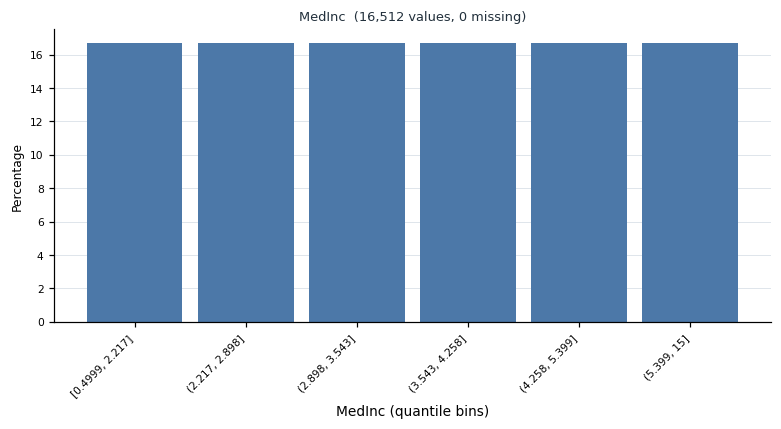

In [22]:
# save=True uses Results_of_DataProfiling/MedInc_histogram.png.
show(profiling.histogram_figure(distributions["MedInc"], show_percentage=True, save=True))

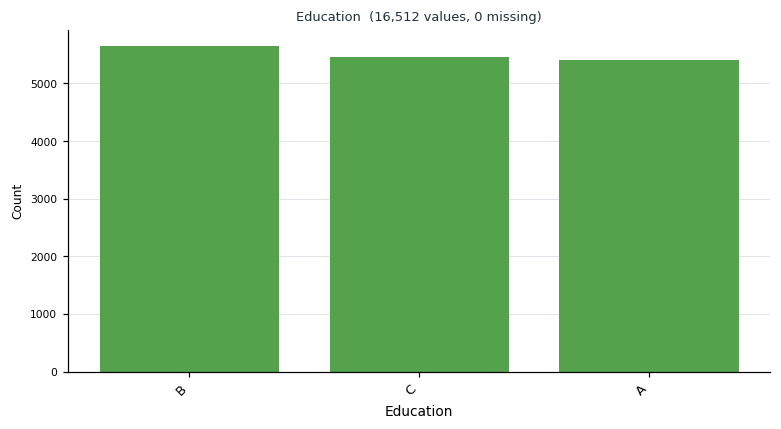

In [23]:
show(
    profiling.histogram_figure(
        distributions["Education"],
        color=profiling.PALETTE[2],
        save=IMAGES / "education_distribution.png",
    )
)

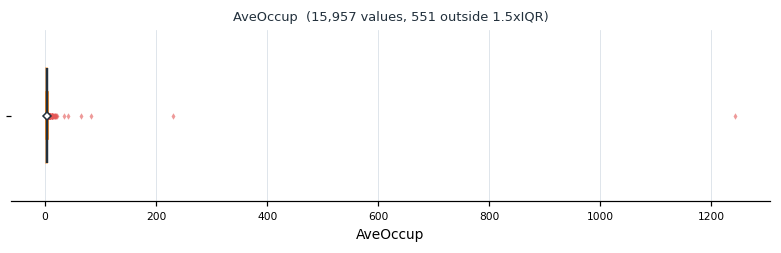

In [24]:
show(
    profiling.box_figure(
        boxes["AveOccup"],
        color=profiling.PALETTE[1],
        save=IMAGES / "ave_occupancy_outliers.png",
    )
)

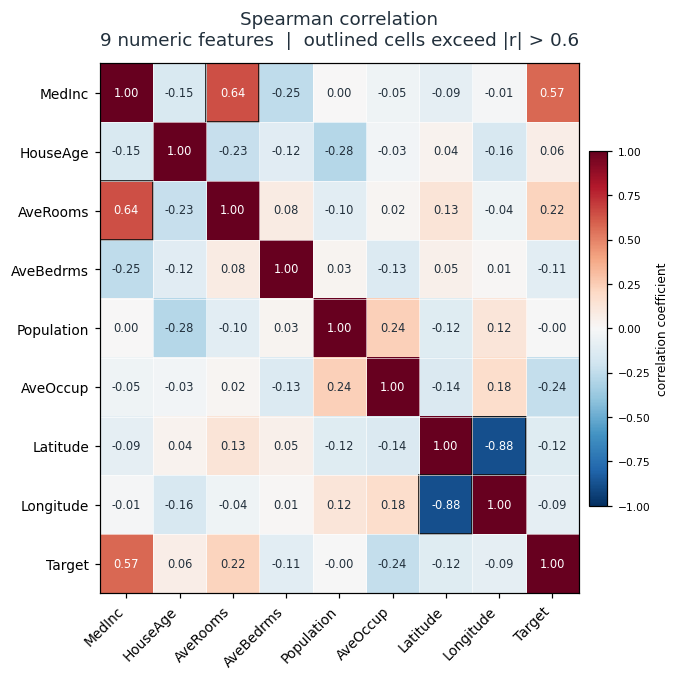

In [25]:
show(
    profiling.heatmap_figure(
        matrices["spearman"],
        "spearman",
        threshold=0.6,
        fit_page=False,
        save=IMAGES / "spearman_correlation.png",
    )
)

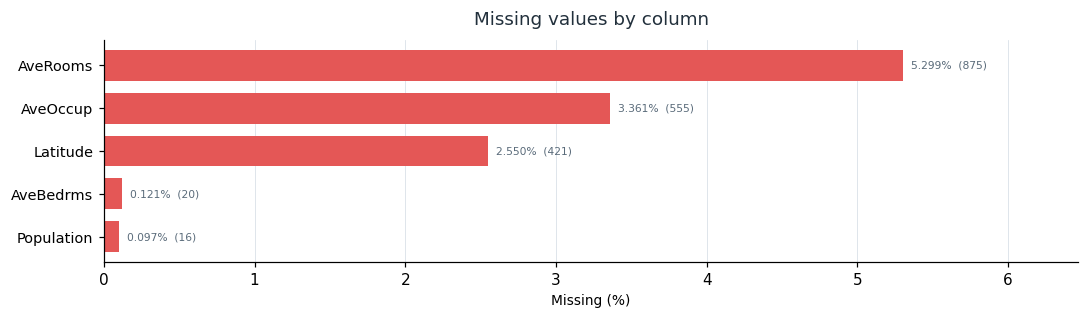

In [26]:
show(
    profiling.missing_bar_figure(
        profiling.missing_count(df),
        fit_page=False,
        save=IMAGES / "missing_values.png",
    )
)

`dataframe_figure` renders any table as a single blue, publication-ready image. Long headers
wrap onto at most two lines, numbers are aligned, and percentage columns use three decimals.
Its colors, fonts, wrapping and output address can all be customized directly:

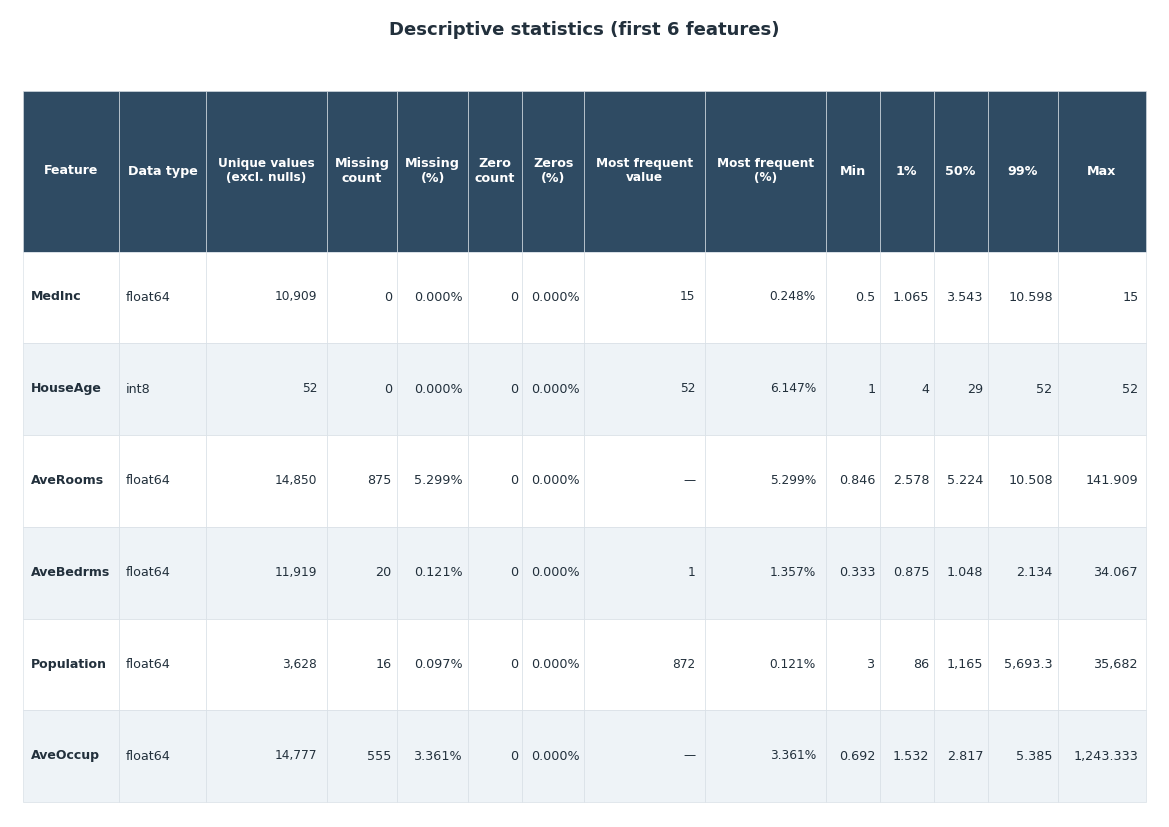

In [27]:
show(
    profiling.dataframe_figure(
        profiling.describe_data(df).head(6),
        title="Descriptive statistics (first 6 features)",
        show_index=True,
        fit_page=True,
        save=IMAGES / "descriptive_statistics.png",
    ),
    dpi=100,
    crop=False,
)

The grid builders paginate onto the shared A4 landscape page used by the PDF:

2 page(s)


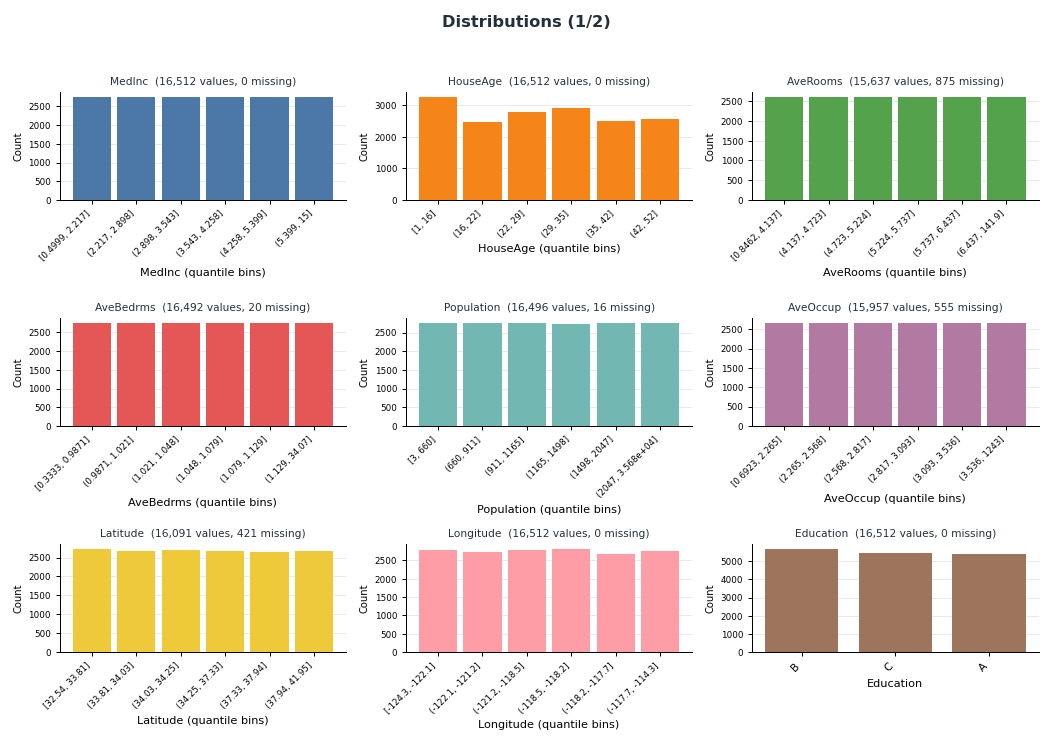

In [28]:
pages = profiling.histogram_grid_figures(
    list(distributions.values()),
    n_cols=3,
    n_rows=3,
    save=IMAGES / "distribution_grid.png",
)
print(len(pages), "page(s)")
show(pages[0], dpi=90, crop=False)

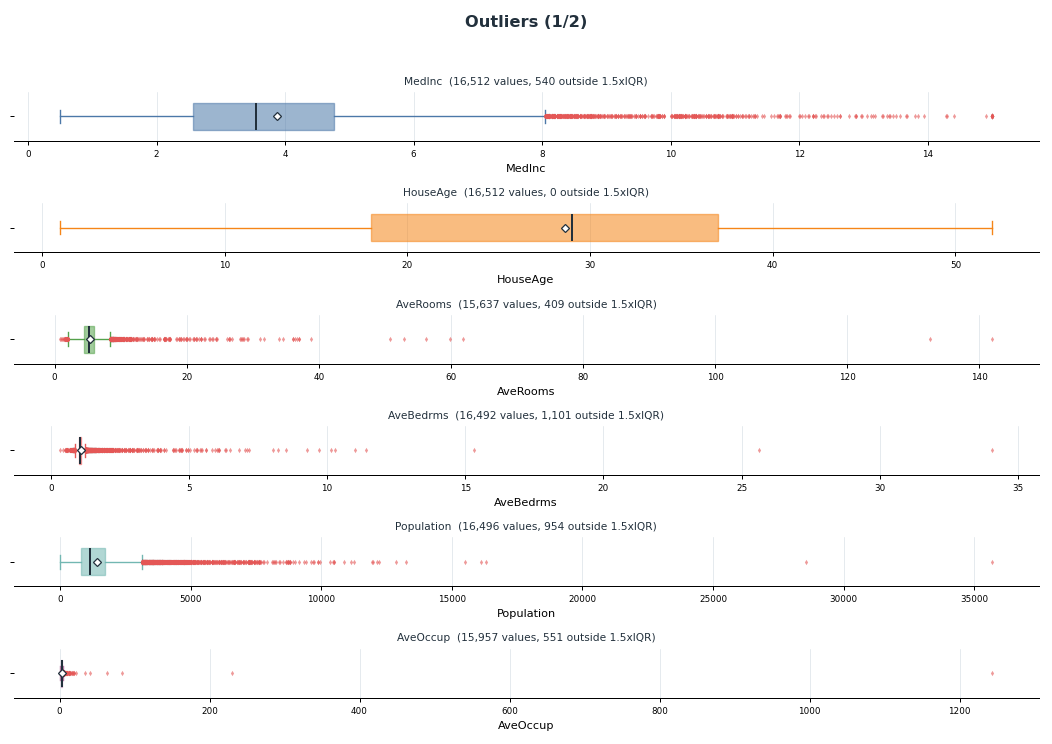

In [29]:
box_pages = profiling.box_grid_figures(
    list(boxes.values()),
    n_rows=6,
    save=IMAGES / "outlier_grid.png",
)
show(box_pages[0], dpi=90, crop=False)

`save=True` chooses a clear default name; `save=address` uses your address and creates its
parent folders. Grid builders add `_01`, `_02`, ... when they need several pages. The lower-level
`save_figure` and `figure_to_png` helpers remain available when you already have a figure:

In [30]:
default_target = IMAGES / "MedInc_histogram.png"
print("save=True ->", default_target.relative_to(ROOT).as_posix(), f"({default_target.stat().st_size:,} bytes)")

print("custom addresses:")
for target in sorted(IMAGES.glob("*.png")):
    print(f"  {target.name:<34} {target.stat().st_size:>10,} bytes")

save=True -> Results_of_DataProfiling/MedInc_histogram.png (41,819 bytes)
custom addresses:
  ave_occupancy_outliers.png             17,912 bytes
  descriptive_statistics.png            146,472 bytes
  distribution_grid_01.png              256,067 bytes
  distribution_grid_02.png               43,205 bytes
  education_distribution.png             23,711 bytes
  MedInc_histogram.png                   41,819 bytes
  missing_values.png                     43,036 bytes
  outlier_grid_01.png                   129,123 bytes
  outlier_grid_02.png                    57,958 bytes
  spearman_correlation.png              149,142 bytes


---
## 9. Interactive figures (Plotly)

The same summaries, rendered for the browser. This is exactly what the dashboard shows.

In [31]:
profiling.plots.histogram_figure(distributions["MedInc"], show_percentage=True)

In [32]:
profiling.plots.box_figure(boxes["AveOccup"])

In [33]:
profiling.plots.correlation_heatmap(matrices["spearman"], "spearman", threshold=0.6)

---
## 10. The whole thing in one call

`ProfilingSettings` captures everything that influences the numbers, and the entire object is
written into the exported metadata — so a report can always be traced back to the
configuration that produced it.

In [34]:
settings = profiling.ProfilingSettings(
    include_describe=True,
    include_missing=True,
    include_correlation=True,
    include_histograms=True,
    include_box_plots=True,
    correlation_methods=("pearson", "spearman"),
    correlation_threshold=0.6,
    binning=profiling.QUANTILE,
    n_bins=8,
    show_percentage=True,
    random_state=0,
)
settings

ProfilingSettings(selected_features=(), include_describe=True, include_missing=True, include_correlation=True, include_histograms=True, include_box_plots=True, correlation_methods=('pearson', 'spearman'), correlation_threshold=0.6, correlation_max_rows=None, binning='quantile', n_bins=8, max_categories=30, show_percentage=True, random_state=0)

In [35]:
result = profiling.run_profiling(
    df,
    settings,
    dataset_name="HousingData_TrainData.csv",
    dtype_labels=train.original_dtypes,
    source_info={
        "parser": train.parser,
        "delimiter": train.delimiter,
        "token": train.token,
        "memory_saved_mb": train.memory_saved_mb,
    },
    progress=lambda label, fraction: print(f"  {fraction:5.0%}  {label}"),
)

print()
print(f"rows            {result.n_rows:,}")
print(f"numeric features {len(result.numeric_features)}")
print(f"in-memory        {result.memory_mb:.2f} MB")
print(f"total            {result.total_seconds:.3f} s")
print("timings         ", {k: round(v, 4) for k, v in result.timings.items()})
print("notes           ", result.notes)

    20%  Descriptive statistics
    40%  Missing values
    60%  Correlation analysis
    80%  Distributions
   100%  Box plots
   100%  Done

rows            16,512
numeric features 9
in-memory        0.93 MB
total            0.153 s
timings          {'descriptive_statistics': 0.0121, 'missing_values': 0.0025, 'correlation': 0.1155, 'distributions': 0.0136, 'box_plots': 0.0092}
notes            ['1 non-numeric feature(s) are excluded from correlation and box-plot analysis: Education']


In [36]:
result.describe

,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
MedInc,float64,10909,0,0.000,0,0.000,15.0001,0.248,0.499900,1.064811,3.543200,10.597660,15.000100
HouseAge,int64,52,0,0.000,0,0.000,52.0000,6.147,1.000000,4.000000,29.000000,52.000000,52.000000
AveRooms,float64,14850,875,5.299,0,0.000,NaN,5.299,0.846154,2.578239,5.223796,10.508205,141.909091
AveBedrms,float64,11919,20,0.121,0,0.000,1.0000,1.357,0.333333,0.874933,1.048338,2.134243,34.066667
Population,float64,3628,16,0.097,0,0.000,872.0000,0.121,3.000000,86.000000,1165.000000,5693.300000,35682.000000
AveOccup,float64,14777,555,3.361,0,0.000,NaN,3.361,0.692308,1.532372,2.817391,5.384688,1243.333333
Latitude,float64,833,421,2.550,0,0.000,NaN,2.550,32.540000,32.680000,34.250000,40.641000,41.950000
Longitude,float64,819,0,0.000,0,0.000,-118.3000,0.824,-124.350000,-123.220000,-118.480000,-116.281100,-114.310000
Target,int64,2,0,0.000,8244,49.927,1.0000,50.073,0.000000,0.000000,1.000000,1.000000,1.000000


In [37]:
result.top_correlations["spearman"]

,Feature 1,Feature 2,absolute spearman correlation values
0,Latitude,Longitude,0.877575
1,MedInc,AveRooms,0.642735


The run is self-describing. `metadata()` is JSON-serialisable and records the dataset, the settings, the timings and the library versions:

In [38]:
print(json.dumps(result.metadata(), indent=2, default=str)[:1800], "...")

{
  "report_format_version": "2.1.0",
  "dataset": {
    "name": "HousingData_TrainData.csv",
    "n_rows": 16512,
    "n_columns_total": 10,
    "n_columns_selected": 10,
    "numeric_features": [
      "MedInc",
      "HouseAge",
      "AveRooms",
      "AveBedrms",
      "Population",
      "AveOccup",
      "Latitude",
      "Longitude",
      "Target"
    ],
    "dtypes": {
      "MedInc": "float64",
      "HouseAge": "int64",
      "AveRooms": "float64",
      "AveBedrms": "float64",
      "Population": "float64",
      "AveOccup": "float64",
      "Latitude": "float64",
      "Longitude": "float64",
      "Education": "object",
      "Target": "int64"
    },
    "in_memory_size_mb": 0.9294,
    "parser": "pyarrow",
    "delimiter": ",",
    "token": "765aa8cdf27d9d69a5a9129874c74b2a",
    "memory_saved_mb": 0.9918193817138672
  },
  "settings": {
    "selected_features": [
      "MedInc",
      "HouseAge",
      "AveRooms",
      "AveBedrms",
      "Population",
      "AveOccup"

---
## 11. Exporting

Three shapes of the same bundle: a paginated PDF, a ZIP archive, or a plain folder.
`build_zip` and `write_report_dir` share one definition of the contents (`bundle_files`), so
an unpacked archive and a written folder are the same tree.

In [39]:
pdf = profiling.build_pdf(result)
(OUT / "report.pdf").write_bytes(pdf)
print(f"PDF {len(pdf):,} bytes")

# Pass the rendered PDF in so the ZIP does not have to re-render it.
archive = profiling.build_zip(result, pdf_bytes=pdf)
(OUT / f"{profiling.suggested_basename(result)}.zip").write_bytes(archive)
print(f"ZIP {len(archive):,} bytes")

PDF 143,048 bytes


ZIP 1,435,006 bytes


In [40]:
written = profiling.write_report_dir(result, OUT / "report_folder", include_pdf=False)
for path in written:
    print(Path(path).relative_to(OUT / "report_folder"))

metadata.json
01_descriptive_statistics\descriptive_statistics.csv
01_descriptive_statistics\descriptive_statistics.png
02_missing_values\missing_values_all_columns.csv
02_missing_values\missing_values_affected_columns.csv
02_missing_values\missing_values.png
03_correlation\correlation_matrix_pearson.csv
03_correlation\top_correlations_pearson.csv
03_correlation\correlation_heatmap_pearson.png
03_correlation\correlation_matrix_spearman.csv
03_correlation\top_correlations_spearman.csv
03_correlation\correlation_heatmap_spearman.png
03_correlation\correlations.xlsx
04_distributions\histogram_bins.csv
04_distributions\overview_page_01.png
04_distributions\overview_page_02.png
04_distributions\by_feature\001_MedInc.png
04_distributions\by_feature\002_HouseAge.png
04_distributions\by_feature\003_AveRooms.png
04_distributions\by_feature\004_AveBedrms.png
04_distributions\by_feature\005_Population.png
04_distributions\by_feature\006_AveOccup.png
04_distributions\by_feature\007_Latitude.png
04

`bundle_files` is the underlying stream, if you want to route the contents somewhere else — object storage, a database, an email attachment:

In [41]:
for name, payload in profiling.bundle_files(result, include_pdf=False, include_individual_charts=False):
    print(f"{len(payload):>9,}  {name}")

    2,195  metadata.json
    1,000  01_descriptive_statistics/descriptive_statistics.csv


  167,001  01_descriptive_statistics/descriptive_statistics.png
      215  02_missing_values/missing_values_all_columns.csv
      142  02_missing_values/missing_values_affected_columns.csv
   43,240  02_missing_values/missing_values.png
      881  03_correlation/correlation_matrix_pearson.csv
      112  03_correlation/top_correlations_pearson.csv


  145,108  03_correlation/correlation_heatmap_pearson.png
      883  03_correlation/correlation_matrix_spearman.csv
      110  03_correlation/top_correlations_spearman.csv


  149,556  03_correlation/correlation_heatmap_spearman.png
    7,966  03_correlation/correlations.xlsx
    5,533  04_distributions/histogram_bins.csv


  262,296  04_distributions/overview_page_01.png
   37,871  04_distributions/overview_page_02.png
    1,106  05_outliers/box_plot_statistics.csv


  129,123  05_outliers/overview_page_01.png
   57,958  05_outliers/overview_page_02.png
    1,986  README.txt


---
## 12. Preparation: collapsing one-hot encodings

Profiling a wide block of 0/1 dummies says very little; profiling the one categorical column
they encode says a lot. Each dummy group is replaced, in the position of its first member, by
a single column.

In [42]:
ohe = profiling.load_table(DATA / "HousingData_OHE_TrainData.csv").frame
print(list(ohe.columns))
ohe[["Education_A", "Education_B", "Education_C"]].head()

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Education_A', 'Education_B', 'Education_C', 'Target']


,Education_A,Education_B,Education_C
0,0.0,0,1
1,0.0,1,0
2,1.0,0,0
3,0.0,1,0
4,0.0,1,0


In [43]:
# "auto" infers the groups from the separator in the column names.
merged = profiling.merge_one_hot_encoded_columns(ohe, separator="_")
print(list(merged.columns))
merged["Education"].value_counts()

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Education', 'Target']


Education
Education_B    6028
Education_C    5450
Education_A    5034
Name: count, dtype: int64

In [44]:
# strip_prefix drops the "<feature><separator>" part of the value.
stripped = profiling.merge_one_hot_encoded_columns(
    ohe, {"Education": ["Education_A", "Education_B", "Education_C"]},
    separator="_", strip_prefix=True,
)
stripped["Education"].value_counts()

Education
B    6028
C    5450
A    5034
Name: count, dtype: int64

In [45]:
# A list of original feature names groups by substring match instead.
profiling.merge_one_hot_encoded_columns(ohe, ["Education"], separator="_").head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Education,Target
0,1.4917,35.0,3.847291,0.992611,1587.0,3.908867,33.93,-118.26,Education_C,0
1,0.5360,4.0,14.000000,3.333333,9.0,3.000000,34.14,-116.76,Education_B,0
2,1.9125,36.0,3.332721,1.029412,1501.0,2.759191,34.14,-118.24,Education_A,1


The input frame is never modified — a copy comes back. Note that a row in which every dummy
is zero is attributed to the first column of its group, because the winner is simply the
largest dummy.

In [46]:
print("original untouched:", list(ohe.columns))

original untouched: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Education_A', 'Education_B', 'Education_C', 'Target']


---
## 13. Preparation: stacking several frames

`combine_datasets` stacks a mapping into one frame with a column recording where each row
came from. That column is excluded from `feature_names`, so it is never profiled as a
feature — and it is exactly what you then group on to compare train against test.

In [47]:
test = profiling.load_table(DATA / "HousingData_TestData.csv")

combined = profiling.combine_datasets({"Train": train.frame, "Test": test.frame})
print("shape        ", combined.frame.shape)
print("tag column   ", combined.tag_column)
print("sources      ", combined.sources)
print("features     ", combined.feature_names)
combined.frame["Dataset"].value_counts()

shape         (20640, 11)
tag column    Dataset
sources       {'Train': 16512, 'Test': 4128}
features      ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Education', 'Target']


Dataset
Train    16512
Test      4128
Name: count, dtype: int64

A single frame passed in comes back untouched, with `tag_column=None`. That lets a caller route its input through this function without special-casing:

In [48]:
passthrough = profiling.combine_datasets(df)
print("is_combined:", passthrough.is_combined, "| tag_column:", passthrough.tag_column)
print("same object:", passthrough.frame is df)

is_combined: False | tag_column: None
same object: True


---
## 14. Segmentation

This is the capability the dashboard does not expose. A dataset can be split four ways, and
every analysis is then run per segment.

| Call | Split |
|---|---|
| `make_grouping(df, "Education")` | one segment per distinct value |
| `make_grouping(df, "HouseAge", bins=[(1, 20), (20, 50)])` | explicit right-closed intervals |
| `make_grouping(df, "HouseAge", n_bins=4)` | four equal-width intervals |
| `make_grouping(df, "HouseAge", n_quantiles=4)` | four equal-frequency intervals |

A `Grouping` holds only row indices, never data, so building one is cheap and the same
grouping can be reused for several analyses.

In [49]:
by_value = profiling.make_grouping(df, "Education")
print(by_value.method, "|", by_value.grouping_var, "|", by_value.labels)
by_value.to_frame()

values | Education | ['Education=A', 'Education=B', 'Education=C']


,segment,label,n_rows,share_of_rows_%
0,A,Education=A,5412,32.7762
1,B,Education=B,5650,34.2175
2,C,Education=C,5450,33.0063


In [50]:
by_interval = profiling.make_grouping(df, "HouseAge", bins=[(1, 20), (20, 50)])
print(by_interval.labels)
print(f"{by_interval.n_rows_unassigned:,} rows fall outside every interval and belong to no segment")
by_interval.to_frame()

['HouseAge=(1, 20]', 'HouseAge=(20, 50]']
1,057 rows fall outside every interval and belong to no segment


,segment,label,n_rows,share_of_rows_%
0,"(1, 20]","HouseAge=(1, 20]",5031,30.4688
1,"(20, 50]","HouseAge=(20, 50]",10424,63.1298


In [51]:
# Equal-width: even intervals, uneven occupancy. A bin can even come out empty.
profiling.make_grouping(df, "HouseAge", n_bins=4).to_frame()

,segment,label,n_rows,share_of_rows_%
0,"(0.949, 13.75]","HouseAge=(0.949, 13.75]",1875,11.3554
1,"(13.75, 26.5]","HouseAge=(13.75, 26.5]",5532,33.5029
2,"(26.5, 39.25]","HouseAge=(26.5, 39.25]",5764,34.9079
3,"(39.25, 52.0]","HouseAge=(39.25, 52.0]",3341,20.2338


In [52]:
# Quantiles: uneven intervals, even occupancy.
by_quantile = profiling.make_grouping(df, "HouseAge", n_quantiles=4)
by_quantile.to_frame()

,segment,label,n_rows,share_of_rows_%
0,"(0.999, 18.0]","HouseAge=(0.999, 18.0]",4273,25.8781
1,"(18.0, 29.0]","HouseAge=(18.0, 29.0]",4230,25.6177
2,"(29.0, 37.0]","HouseAge=(29.0, 37.0]",4036,24.4428
3,"(37.0, 52.0]","HouseAge=(37.0, 52.0]",3973,24.0613


`by` also accepts a Series or a bare array, so a segment can be defined by something that is not a column:

In [53]:
derived = (df["MedInc"] > df["MedInc"].median()).rename("AboveMedianIncome")
profiling.make_grouping(df, derived).to_frame()

,segment,label,n_rows,share_of_rows_%
0,False,AboveMedianIncome=False,8256,50.0
1,True,AboveMedianIncome=True,8256,50.0


Iterating a grouping slices the frame lazily, one segment at a time:

In [54]:
for segment, subset in by_quantile.frames(df):
    print(f"{segment.label:<28} {segment.n_rows:>6,} rows   "
          f"mean MedInc {subset['MedInc'].mean():.3f}")

HouseAge=(0.999, 18.0]        4,273 rows   mean MedInc 4.235
HouseAge=(18.0, 29.0]         4,230 rows   mean MedInc 3.888
HouseAge=(29.0, 37.0]         4,036 rows   mean MedInc 3.824
HouseAge=(37.0, 52.0]         3,973 rows   mean MedInc 3.548


In [55]:
# Indexing by key or by position, and the guard against ambiguous requests.
print(by_quantile[0].label)
print(by_quantile[by_quantile.keys[-1]].n_rows)
try:
    profiling.make_grouping(df, "HouseAge", n_bins=4, n_quantiles=4)
except ValueError as exc:
    print("guarded:", exc)

HouseAge=(0.999, 18.0]
3973
guarded: Choose at most one of bins, n_bins or n_quantiles; got equal-width, quantile.


---
## 15. Profiling every segment

`run_segmented_profiling` applies the identical settings to every segment — that is what
keeps the numbers comparable — and returns one ordinary `ProfilingResult` per segment. So
anything that renders or exports a single run also handles one segment of a segmented run,
with no second code path.

In [56]:
segmented = profiling.run_segmented_profiling(
    df,
    settings,
    by="HouseAge",
    n_quantiles=4,
    dataset_name="HousingData_TrainData.csv",
)

print(f"grouping   {segmented.grouping_var} ({segmented.method})")
print(f"segments   {len(segmented)}")
print(f"total      {segmented.total_seconds:.3f} s")
print(f"notes      {segmented.notes}")
segmented.segment_overview()

grouping   HouseAge (quantile)
segments   4
total      0.142 s
notes      []


,segment,n_rows,share_of_rows_%,n_features,n_numeric_features,memory_mb,seconds
0,"(0.999, 18.0]",4273,25.8781,10,9,0.2733,0.0350
1,"(18.0, 29.0]",4230,25.6177,10,9,0.2705,0.0384
2,"(29.0, 37.0]",4036,24.4428,10,9,0.2581,0.0345
3,"(37.0, 52.0]",3973,24.0613,10,9,0.2541,0.0345


In [57]:
# Each segment is a plain ProfilingResult.
one = segmented[segmented.keys[0]]
print(type(one).__name__, "|", one.dataset_name)
one.describe.head()

ProfilingResult | HousingData_TrainData.csv [HouseAge=(0.999, 18.0]]


,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
MedInc,float64,3746,0,0.000,0,0.0,3.0,0.257,0.4999,1.118076,3.960700,10.408236,15.000100
HouseAge,int8,18,0,0.000,0,0.0,16.0,14.650,1.0000,2.000000,14.000000,18.000000,18.000000
AveRooms,float64,4004,221,5.172,0,0.0,NaN,5.172,1.0000,2.870065,5.705152,17.051375,56.269231
AveBedrms,float64,3910,9,0.211,0,0.0,1.0,1.030,0.5000,0.890318,1.061407,3.150988,11.410714
Population,float64,2539,6,0.140,0,0.0,1158.0,0.187,3.0000,69.000000,1440.000000,7986.320000,35682.000000


The comparison methods return long-format frames with a `segment` column in front — the
shape that pivots, plots and diffs cleanly.

In [58]:
comparison = segmented.describe_comparison()
print(comparison.shape)
comparison.head(12)

(36, 15)


,segment,feature,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
0,"(0.999, 18.0]",MedInc,float64,3746,0,0.000,0,0.000,3.000,0.257,0.499900,1.118076,3.960700,10.408236,15.000100
1,"(0.999, 18.0]",HouseAge,int8,18,0,0.000,0,0.000,16.000,14.650,1.000000,2.000000,14.000000,18.000000,18.000000
2,"(0.999, 18.0]",AveRooms,float64,4004,221,5.172,0,0.000,NaN,5.172,1.000000,2.870065,5.705152,17.051375,56.269231
3,"(0.999, 18.0]",AveBedrms,float64,3910,9,0.211,0,0.000,1.000,1.030,0.500000,0.890318,1.061407,3.150988,11.410714
4,"(0.999, 18.0]",Population,float64,2539,6,0.140,0,0.000,1158.000,0.187,3.000000,69.000000,1440.000000,7986.320000,35682.000000
5,"(0.999, 18.0]",AveOccup,float64,4048,140,3.276,0,0.000,NaN,3.276,0.692308,1.508356,2.836257,5.172967,83.171429
6,"(0.999, 18.0]",Latitude,float64,722,106,2.481,0,0.000,NaN,2.481,32.540000,32.650000,34.720000,40.660000,41.950000
7,"(0.999, 18.0]",Longitude,float64,721,0,0.000,0,0.000,-117.250,0.702,-124.300000,-123.202800,-119.030000,-115.857600,-114.310000
8,"(0.999, 18.0]",Target,int8,2,0,0.000,2368,55.418,0.000,55.418,0.000000,0.000000,0.000000,1.000000,1.000000
9,"(18.0, 29.0]",MedInc,float64,3635,0,0.000,0,0.000,2.625,0.260,0.499900,1.089090,3.505400,10.355904,15.000100


In [59]:
# The median of every feature, segment by segment.
comparison.pivot(index="feature", columns="segment", values="50%").round(3)

segment,"(0.999, 18.0]","(18.0, 29.0]","(29.0, 37.0]","(37.0, 52.0]"
feature,,,,
AveBedrms,1.061,1.050,1.038,1.046
AveOccup,2.836,2.832,2.903,2.673
AveRooms,5.705,5.257,5.133,4.883
HouseAge,14.000,24.000,34.000,45.000
Latitude,34.720,34.280,34.130,34.350
Longitude,-119.030,-118.750,-118.350,-118.990
MedInc,3.961,3.505,3.572,3.165
Population,1440.000,1333.000,1098.000,940.000
Target,0.000,1.000,1.000,1.000


In [60]:
segmented.missing_comparison(affected_only=True)

,segment,feature,number_of_missing,percentage_of_missing
0,"(0.999, 18.0]",AveRooms,221,5.1720
1,"(0.999, 18.0]",AveOccup,140,3.2764
2,"(0.999, 18.0]",Latitude,106,2.4807
3,"(0.999, 18.0]",AveBedrms,9,0.2106
4,"(0.999, 18.0]",Population,6,0.1404
5,"(18.0, 29.0]",AveRooms,226,5.3428
6,"(18.0, 29.0]",AveOccup,140,3.3097
7,"(18.0, 29.0]",Latitude,104,2.4586
8,"(18.0, 29.0]",AveBedrms,3,0.0709
9,"(18.0, 29.0]",Population,2,0.0473


In [61]:
segmented.box_comparison()[
    ["segment", "feature", "median", "iqr", "n_outliers", "perc_outliers"]
].head(12)

,segment,feature,median,iqr,n_outliers,perc_outliers
0,"(0.999, 18.0]",MedInc,3.960700,2.373200,92,2.1531
1,"(0.999, 18.0]",HouseAge,14.000000,6.000000,0,0.0000
2,"(0.999, 18.0]",AveRooms,5.705152,1.707730,143,3.5291
3,"(0.999, 18.0]",AveBedrms,1.061407,0.107416,405,9.4981
4,"(0.999, 18.0]",Population,1440.000000,1303.000000,281,6.5854
5,"(0.999, 18.0]",AveOccup,2.836257,0.795739,100,2.4195
6,"(0.999, 18.0]",Latitude,34.720000,4.030000,0,0.0000
7,"(0.999, 18.0]",Longitude,-119.030000,3.790000,0,0.0000
8,"(0.999, 18.0]",Target,0.000000,1.000000,0,0.0000
9,"(18.0, 29.0]",MedInc,3.505400,2.255125,124,2.9314


In [62]:
segmented.distribution_comparison().head(10)

,segment,feature,type,binning,bin,bin_label,bin_lower,bin_upper,count,percentage,n_missing
0,"(0.999, 18.0]",MedInc,numeric,quantile,1,"[0.4999, 2.287]",0.4999,2.2868,535,12.520477,0
1,"(0.999, 18.0]",MedInc,numeric,quantile,2,"(2.287, 2.886]",2.2868,2.8864,534,12.497075,0
2,"(0.999, 18.0]",MedInc,numeric,quantile,3,"(2.886, 3.406]",2.8864,3.4058,534,12.497075,0
3,"(0.999, 18.0]",MedInc,numeric,quantile,4,"(3.406, 3.961]",3.4058,3.9607,534,12.497075,0
4,"(0.999, 18.0]",MedInc,numeric,quantile,5,"(3.961, 4.521]",3.9607,4.5208,535,12.520477,0
5,"(0.999, 18.0]",MedInc,numeric,quantile,6,"(4.521, 5.26]",4.5208,5.2596,533,12.473672,0
6,"(0.999, 18.0]",MedInc,numeric,quantile,7,"(5.26, 6.324]",5.2596,6.3237,534,12.497075,0
7,"(0.999, 18.0]",MedInc,numeric,quantile,8,"(6.324, 15]",6.3237,15.0001,534,12.497075,0
8,"(0.999, 18.0]",HouseAge,numeric,quantile,1,"[1, 6]",1.0000,6.0000,574,13.433185,0
9,"(0.999, 18.0]",HouseAge,numeric,quantile,2,"(6, 10]",6.0000,10.0000,682,15.960683,0


`top_correlation_comparison` stacks the above-threshold pairs per segment. A pair listed for
one segment and not another is the interesting case: it cleared the threshold there and not
here.

In [63]:
segmented.top_correlation_comparison("spearman")

,segment,method,Feature 1,Feature 2,absolute_correlation
0,"(0.999, 18.0]",spearman,Latitude,Longitude,0.879216
1,"(18.0, 29.0]",spearman,Latitude,Longitude,0.891223
2,"(18.0, 29.0]",spearman,MedInc,AveRooms,0.643384
3,"(29.0, 37.0]",spearman,Latitude,Longitude,0.847418
4,"(29.0, 37.0]",spearman,MedInc,AveRooms,0.662151
5,"(37.0, 52.0]",spearman,Latitude,Longitude,0.813831
6,"(37.0, 52.0]",spearman,MedInc,AveRooms,0.621332
7,"(37.0, 52.0]",spearman,MedInc,Target,0.610495


`correlation_comparison` is built from the **full** matrices instead, so every pair is
present in every segment and the row can be read across. Sorted by spread, the top rows are
the relationships that appear, vanish or flip sign between segments.

In [64]:
drift = segmented.correlation_comparison("pearson")
drift.head(8).round(3)

,Feature 1,Feature 2,"(0.999, 18.0]","(18.0, 29.0]","(29.0, 37.0]","(37.0, 52.0]",max_abs_difference
0,AveRooms,AveBedrms,0.848,0.833,0.927,0.268,0.659
1,MedInc,AveRooms,0.280,0.339,0.212,0.669,0.457
2,HouseAge,Longitude,-0.117,0.027,0.029,-0.261,0.290
3,HouseAge,Latitude,0.100,-0.065,-0.042,0.222,0.288
4,AveOccup,Target,-0.044,-0.165,-0.308,-0.029,0.278
5,MedInc,AveOccup,0.041,-0.024,-0.168,0.051,0.219
6,HouseAge,Target,-0.031,0.036,0.014,0.185,0.216
7,AveRooms,Target,0.127,0.068,0.079,0.279,0.211


In [65]:
# Same thing, restricted to pairs that are actually strong somewhere.
segmented.correlation_comparison("spearman", min_abs=0.5).round(3)

,Feature 1,Feature 2,"(0.999, 18.0]","(18.0, 29.0]","(29.0, 37.0]","(37.0, 52.0]",max_abs_difference
0,Latitude,Longitude,-0.879,-0.891,-0.847,-0.814,0.077
1,MedInc,AveRooms,0.593,0.643,0.662,0.621,0.069
2,MedInc,Target,0.594,0.583,0.592,0.610,0.027


When segmenting on distinct values the grouping column is constant inside each segment, so
its own profile is degenerate. The run says so in its notes, and
`include_grouping_column=False` leaves it out.

In [66]:
kept = profiling.run_segmented_profiling(df, settings, by="Education")
print("notes:", kept.notes)

dropped = profiling.run_segmented_profiling(
    df, settings, by="Education", include_grouping_column=False
)
print("with column   ", len(kept.settings.selected_features), "features")
print("without column", len(dropped.settings.selected_features), "features")

notes: ["'Education' is constant within each segment; its per-segment profile is degenerate. Pass include_grouping_column=False to omit it."]


with column    10 features
without column 9 features


With `by=None` the whole dataset becomes the single segment `Data=All`, so a caller can always take the segmented path:

In [67]:
ungrouped = profiling.run_segmented_profiling(df, settings)
print(ungrouped.keys, "|", ungrouped.grouping.method)

['All'] | none


---
## 16. Train vs test drift

Combine the two frames, then segment on the tag column. Two lines, and every comparison table
above becomes a drift report.

In [68]:
drift_run = profiling.run_segmented_profiling(
    {"Train": train.frame, "Test": test.frame},
    settings,
    by="Dataset",
    dataset_name="HousingData",
)
print(drift_run.keys)
drift_run.segment_overview()

['Test', 'Train']


,segment,n_rows,share_of_rows_%,n_features,n_numeric_features,memory_mb,seconds
0,Test,4128,20.0,10,9,0.2640,0.0330
1,Train,16512,80.0,10,9,1.0553,0.1286


In [69]:
medians = drift_run.describe_comparison().pivot(index="feature", columns="segment", values="50%")
medians["shift_%"] = ((medians["Test"] - medians["Train"]) / medians["Train"] * 100).round(2)
medians.round(4)

segment,Test,Train,shift_%
feature,,,
AveBedrms,1.0499,1.0483,0.15
AveOccup,2.8318,2.8174,0.51
AveRooms,5.2332,5.2238,0.18
HouseAge,28.5000,29.0000,-1.72
Latitude,34.2900,34.2500,0.12
Longitude,-118.5400,-118.4800,0.05
MedInc,3.5053,3.5432,-1.07
Population,1171.0000,1165.0000,0.52
Target,0.0000,1.0000,-100.00


In [70]:
outliers = drift_run.box_comparison().pivot(
    index="feature", columns="segment", values="perc_outliers"
)
outliers.round(3)

segment,Test,Train
feature,,
AveBedrms,7.792,6.676
AveOccup,3.351,3.453
AveRooms,2.411,2.616
HouseAge,0.000,0.000
Latitude,0.000,0.000
Longitude,0.000,0.000
MedInc,3.343,3.270
Population,5.950,5.783
Target,0.000,0.000


In [71]:
drift_run.correlation_comparison("pearson").head(6).round(3)

,Feature 1,Feature 2,Test,Train,max_abs_difference
0,AveOccup,Latitude,0.016,-0.051,0.066
1,HouseAge,AveBedrms,-0.114,-0.071,0.043
2,AveRooms,AveBedrms,0.818,0.857,0.039
3,AveBedrms,Target,-0.089,-0.052,0.037
4,HouseAge,AveRooms,-0.183,-0.146,0.036
5,Longitude,Target,-0.016,-0.049,0.034


---
## 17. Exporting a segmented run

One full bundle folder per segment, plus a `00_comparison/` folder holding the tables that
span every segment. The grouping is visible from the file tree alone.

In [72]:
tree = profiling.write_segmented_report_dir(
    segmented, OUT / "segmented", include_pdf=False, include_individual_charts=False
)

for key, paths in tree.items():
    print(f"{key:<28} {len(paths):>3} files")

00_comparison                 10 files
(0.999, 18.0]                 20 files
(18.0, 29.0]                  20 files
(29.0, 37.0]                  20 files
(37.0, 52.0]                  20 files


In [73]:
root = OUT / "segmented"
for folder in sorted(p for p in root.iterdir() if p.is_dir()):
    print(folder.name + "/")
    for item in sorted(folder.rglob("*")):
        if item.is_file():
            print("   ", item.relative_to(folder).as_posix())

00_comparison/
    box_plot_statistics.csv
    correlation_by_segment_pearson.csv
    correlation_by_segment_spearman.csv
    descriptive_statistics.csv
    histogram_bins.csv
    metadata.json
    missing_values.csv
    segment_overview.csv
    segments.csv
    top_correlations.csv
HouseAge=(0.999, 18.0]/
    01_descriptive_statistics/descriptive_statistics.csv
    01_descriptive_statistics/descriptive_statistics.png
    02_missing_values/missing_values.png
    02_missing_values/missing_values_affected_columns.csv
    02_missing_values/missing_values_all_columns.csv
    03_correlation/correlation_heatmap_pearson.png
    03_correlation/correlation_heatmap_spearman.png
    03_correlation/correlation_matrix_pearson.csv
    03_correlation/correlation_matrix_spearman.csv
    03_correlation/correlations.xlsx
    03_correlation/top_correlations_pearson.csv
    03_correlation/top_correlations_spearman.csv
    04_distributions/histogram_bins.csv
    04_distributions/overview_page_01.png
    04

In [74]:
pd.read_csv(root / "00_comparison" / "segment_overview.csv")

,segment,n_rows,share_of_rows_%,n_features,n_numeric_features,memory_mb,seconds
0,"(0.999, 18.0]",4273,25.8781,10,9,0.2733,0.0350
1,"(18.0, 29.0]",4230,25.6177,10,9,0.2705,0.0384
2,"(29.0, 37.0]",4036,24.4428,10,9,0.2581,0.0345
3,"(37.0, 52.0]",3973,24.0613,10,9,0.2541,0.0345


---
## 18. A wider dataset

Thirty numeric features, so the Kendall path and the pair ranking get a real workout. Kendall
is the one correlation that cannot be reduced to a matrix product — every pair needs its own
O(n log n) inversion count — so its 435 pairs are spread over a thread pool.

In [75]:
cancer = profiling.load_table(DATA / "BreastCancer_TrainData.csv")
print(f"{cancer.n_rows:,} rows x {cancer.n_cols} columns")

wide = profiling.run_profiling(
    cancer.frame,
    profiling.ProfilingSettings(
        correlation_methods=("kendall",),
        correlation_threshold=0.8,
        binning=profiling.EQUAL_WIDTH,
        n_bins=20,
    ),
    dataset_name=cancer.source_name,
)
print(f"{wide.total_seconds:.2f} s   ", {k: round(v, 3) for k, v in wide.timings.items()})
wide.top_correlations["kendall"].head(10).round(4)

455 rows x 31 columns


0.17 s    {'descriptive_statistics': 0.006, 'missing_values': 0.001, 'correlation': 0.153, 'distributions': 0.005, 'box_plots': 0.003}


,Feature 1,Feature 2,absolute kendall correlation values
0,mean radius,mean area,0.9853
1,worst radius,worst area,0.9792
2,mean radius,mean perimeter,0.9611
3,mean perimeter,mean area,0.9543
4,worst radius,worst perimeter,0.9378
5,worst perimeter,worst area,0.9302
6,mean perimeter,worst radius,0.8893
7,mean perimeter,worst area,0.8862
8,mean area,worst radius,0.8862
9,mean radius,worst radius,0.8854


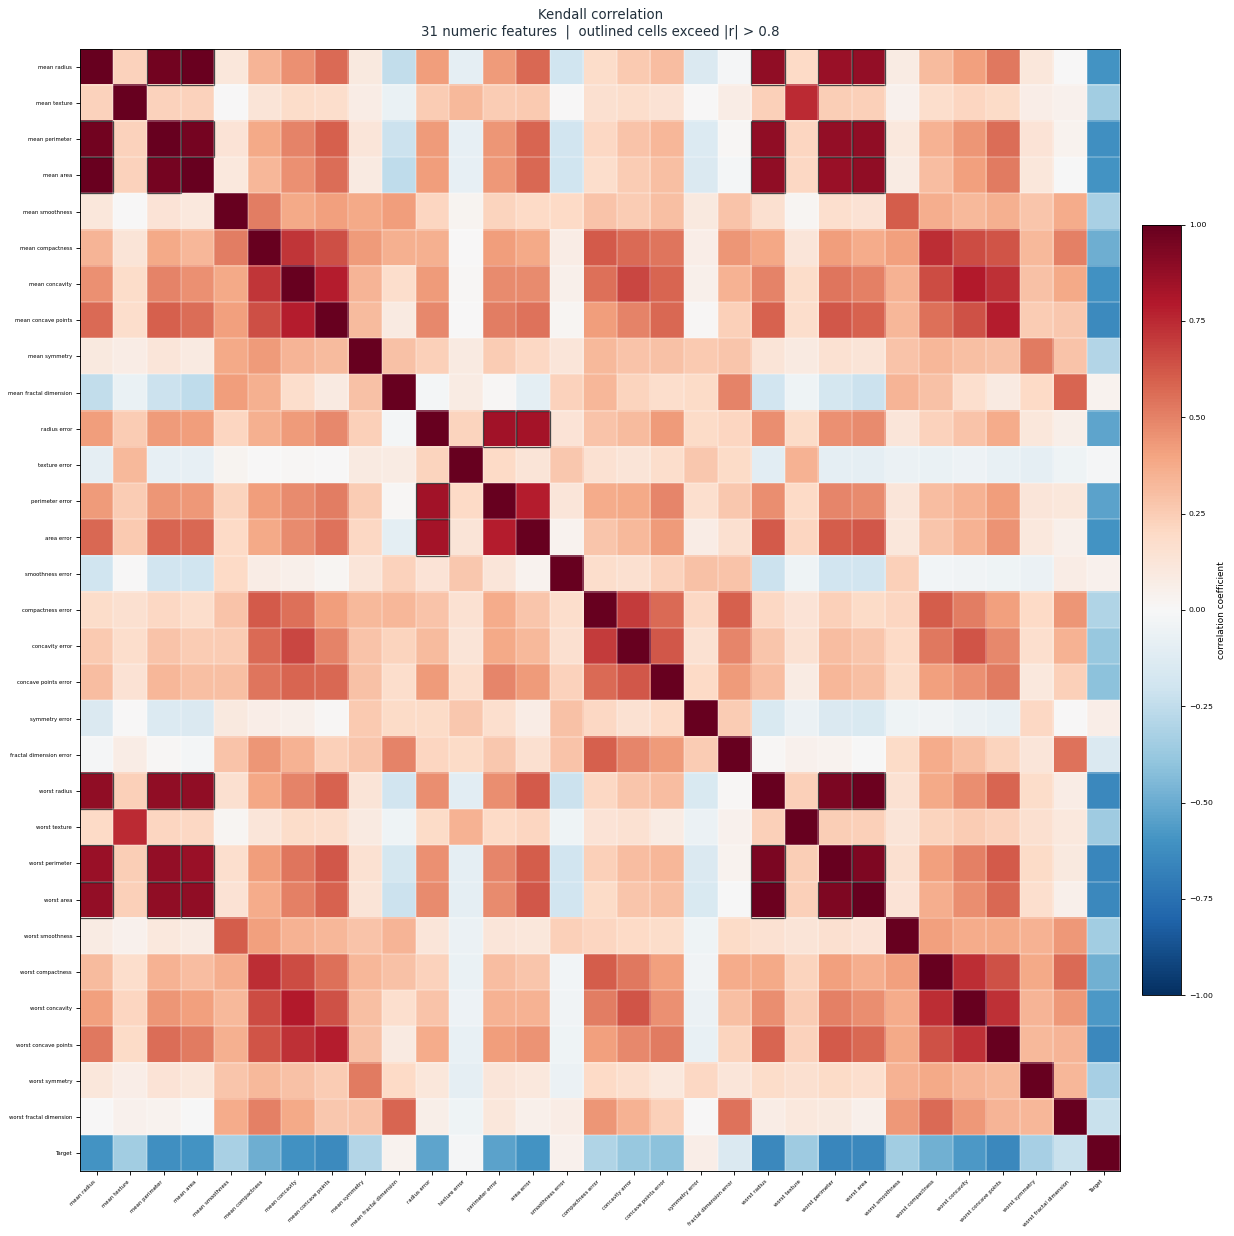

In [76]:
show(
    profiling.heatmap_figure(wide.correlations["kendall"], "kendall", threshold=0.8, fit_page=False),
    dpi=80,
)

Segmenting a wide dataset by the label column is the standard class-imbalance and separability check:

In [77]:
by_target = profiling.run_segmented_profiling(
    cancer.frame,
    profiling.ProfilingSettings(
        include_correlation=False, include_histograms=False, correlation_methods=()
    ),
    by="Target",
    include_grouping_column=False,
    dataset_name=cancer.source_name,
)
by_target.segment_overview()

,segment,n_rows,share_of_rows_%,n_features,n_numeric_features,memory_mb,seconds
0,0,174,38.2418,30,30,0.0412,0.0084
1,1,281,61.7582,30,30,0.0665,0.0091


In [78]:
means = by_target.box_comparison().pivot(index="feature", columns="segment", values="mean")
means["ratio"] = (means["1"] / means["0"]).round(3)
means.sort_values("ratio").round(4).head(10)

segment,0,1,ratio
feature,,,
area error,74.6592,20.7557,0.278
mean concavity,0.1614,0.0451,0.280
mean concave points,0.0886,0.0253,0.286
worst concavity,0.4498,0.1647,0.366
worst area,1441.8552,559.1485,0.388
worst concave points,0.1821,0.0737,0.405
perimeter error,4.4095,1.9518,0.443
radius error,0.6197,0.2780,0.449
mean area,989.2832,463.6735,0.469


---
## 19. Spark and Databricks

The package has **no** Spark dependency and nothing Spark-related is imported until a Spark
object is actually passed in. When one is:

* `make_grouping` bucketises **in Spark** — `Bucketizer` for `bins`/`n_bins` and
  `QuantileDiscretizer` for `n_quantiles` — instead of pulling the grouping column onto the
  driver;
* `combine_datasets` concatenates with `pyspark.pandas`;
* `run_segmented_profiling` materialises one segment at a time, so the driver never holds
  more than a single segment.

So the same call works on a Databricks cluster:

```python
segmented = profiling.run_segmented_profiling(
    spark_df, settings, by="age", n_quantiles=4
)
profiling.write_segmented_report_dir(segmented, "/dbfs/tmp/profiling")
```

`profiling.to_pandas(x)` materialises a Spark frame and passes anything else through
unchanged, so a helper of your own can normalise its input in one line without importing
anything Spark-related.

---
## 20. Cleanup

The large report bundles above used a temporary directory, which is removed here. Images saved
manually with `save=True` or `save=address` remain under `Results_of_DataProfiling/`.

In [79]:
import shutil

print("removing temporary bundle", "<temporary directory>")
shutil.rmtree(OUT, ignore_errors=True)
print("keeping manual images   ", f"{IMAGES.relative_to(ROOT).as_posix()}/")

removing temporary bundle <temporary directory>
keeping manual images    Results_of_DataProfiling/


---
## Cheat sheet

```python
import profiling

# load
loaded = profiling.load_table("data.csv")            # -> LoadedData

# prepare
frame = profiling.merge_one_hot_encoded_columns(loaded.frame, separator="__")
both  = profiling.combine_datasets({"Train": tr, "Test": te})   # -> CombinedData

# analyse, piece by piece
profiling.describe_data(frame)
profiling.missing_count(frame)
profiling.correlation_matrices(frame, ("pearson", "kendall"))
profiling.build_distributions(frame, binning=profiling.QUANTILE, n_bins=8)
profiling.build_box_summaries(frame)

# ...or in one call
settings = profiling.ProfilingSettings(correlation_methods=("spearman",))
result   = profiling.run_profiling(frame, settings, dataset_name="data.csv")

# ...or once per segment
segmented = profiling.run_segmented_profiling(frame, settings, by="age", n_quantiles=4)
segmented.describe_comparison()
segmented.correlation_comparison("spearman")

# export
profiling.dataframe_figure(result.describe, save=True)     # default PNG
profiling.histogram_figure(summary, save="out/hist.png") # custom address
profiling.build_pdf(result)                                  # -> bytes
profiling.build_zip(result)                                  # -> bytes
profiling.write_report_dir(result, "out/")                    # -> [paths]
profiling.write_segmented_report_dir(segmented, "out/")       # -> {segment: [paths]}
```